# Comparaison des Modèles de Machine Learning
## Prédiction de la Gravité des Accidents Routiers — BAAC 2024

---

**Auteurs :** Issam · Noé · Enzo | Projet Data Science 2025-2026

Ce notebook compare les performances des **trois modèles de Machine Learning** entraînés sur le dataset des accidents corporels de la route (France 2024) :

| Modèle | Algorithme | Auteur |
|--------|-----------|--------|
| Régression Logistique | Modèle linéaire multinomial | Issam |
| Random Forest | Forêt aléatoire | Noé |
| XGBoost | Gradient Boosting | Enzo |

**Objectif :** Identifier le meilleur modèle pour prédire la gravité d'un accident routier.

**Variable cible :** Gravité — 3 classes : Blessé léger / Blessé hospitalisé / Tué

## 1. Introduction

### Contexte

Les accidents corporels de la circulation routière représentent un enjeu majeur de sécurité publique.
Ce projet cherche à prédire la **gravité d'un accident** à partir de variables contextuelles
(météo, luminosité, type de route, vitesse autorisée, etc.).

### Données

- **Dataset :** accidents_2024.csv (BAAC France 2024)
- **Nombre d'accidents :** 54 401
- **Features :** 12 variables contextuelles
- **Classes cibles :**
  - Blessé léger : 63.9 %
  - Blessé hospitalisé : 30.2 %
  - Tué : 5.9 %

> **Attention :** La classe **Tué** est très minoritaire (ratio 11×). C'est pourquoi on utilise
> le **F1-score macro** plutôt que l'accuracy seule comme métrique principale.

### Pourquoi comparer les modèles ?

Chaque algorithme a ses forces et faiblesses différentes. Cette comparaison permet de :
1. Identifier le modèle le plus performant globalement
2. Comprendre les différences de comportement entre algorithmes
3. Choisir l'algorithme le mieux adapté au contexte de sécurité routière

## 2. Import des Bibliothèques

In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # pour les positions des barres groupées

# Configuration globale des graphiques
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

print('Bibliothèques importées avec succès !')

Bibliothèques importées avec succès !


## 3. Données de Performance des Modèles

Les métriques ci-dessous ont été obtenues sur le **jeu de test** de chaque modèle, après entraînement.

On utilise les **moyennes macro** (poids égal pour chaque classe), adaptées au déséquilibre des données.

| Modèle | Jeu de test | Protocole |
|--------|-------------|----------|
| Régression Logistique | 10 881 accidents | 80 % train / 20 % test, stratifié |
| Random Forest | 10 881 accidents | 80 % train / 20 % test, stratifié |
| XGBoost | 16 397 accidents | 70 % train / 30 % test, GroupShuffleSplit |

In [2]:
# ==============================================================
# Métriques globales (moyennes macro sur les 3 classes)
# Ces valeurs proviennent des rapports de classification
# de chaque notebook individuel.
# ==============================================================

resultats = {
    'Modèle':            ['Régression Logistique', 'Random Forest', 'XGBoost'],
    'Accuracy':          [0.574, 0.625, 0.649],
    'Précision (macro)': [0.469, 0.457, 0.490],
    'Rappel (macro)':    [0.541, 0.466, 0.510],
    'F1-score (macro)':  [0.455, 0.459, 0.470]
}

df = pd.DataFrame(resultats).set_index('Modèle')

# ==============================================================
# F1-score par classe de gravité
# ==============================================================

resultats_classes = {
    'Modèle':                   ['Régression Logistique', 'Random Forest', 'XGBoost'],
    'F1 — Blessé léger':        [0.750, 0.759, 0.800],
    'F1 — Blessé hospitalisé':  [0.371, 0.442, 0.360],
    'F1 — Tué':                 [0.242, 0.177, 0.240]
}

df_classes = pd.DataFrame(resultats_classes).set_index('Modèle')

print('Données créées !')
print(f'Modèles évalués : {list(df.index)}')

Données créées !
Modèles évalués : ['Régression Logistique', 'Random Forest', 'XGBoost']


## 4. Tableau Comparatif des Performances

In [3]:
# Affichage du tableau des métriques globales
print('Métriques globales (moyennes macro) :')
print('=' * 65)
print(df.round(3).to_string())
print('=' * 65)
print()
print('F1-score détaillé par classe :')
print('=' * 65)
print(df_classes.round(3).to_string())
print('=' * 65)

Métriques globales (moyennes macro) :
                       Accuracy  Précision (macro)  Rappel (macro)  F1-score (macro)
Modèle                                                                              
Régression Logistique     0.574              0.469           0.541             0.455
Random Forest             0.625              0.457           0.466             0.459
XGBoost                   0.649              0.490           0.510             0.470

F1-score détaillé par classe :
                       F1 — Blessé léger  F1 — Blessé hospitalisé  F1 — Tué
Modèle                                                                     
Régression Logistique              0.750                    0.371     0.242
Random Forest                      0.759                    0.442     0.177
XGBoost                            0.800                    0.360     0.240


## 5. Visualisations des Performances

### 5.1 Comparaison Métrique par Métrique

Chaque graphique compare les 3 modèles sur une métrique différente.

**Légende des couleurs :**
- Bleu = Régression Logistique
- Vert = Random Forest
- Rouge = XGBoost

C:\Users\user\AppData\Local\Temp\ipykernel_10828\3366310152.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(modeles, rotation=20, ha='right', fontsize=9)
C:\Users\user\AppData\Local\Temp\ipykernel_10828\3366310152.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(modeles, rotation=20, ha='right', fontsize=9)
C:\Users\user\AppData\Local\Temp\ipykernel_10828\3366310152.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(modeles, rotation=20, ha='right', fontsize=9)
C:\Users\user\AppData\Local\Temp\ipykernel_10828\3366310152.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabel

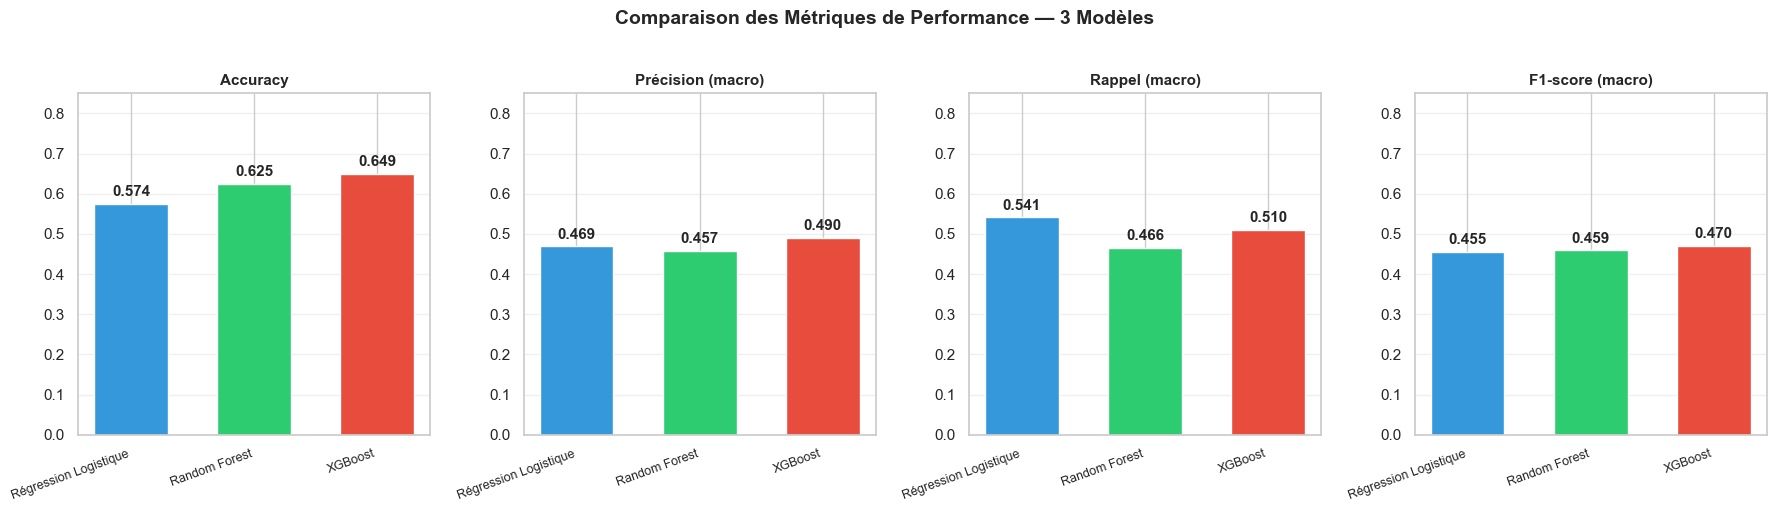

In [4]:
# Couleurs associées à chaque modèle (cohérentes dans tout le notebook)
couleurs = ['#3498db', '#2ecc71', '#e74c3c']  # bleu, vert, rouge
modeles  = df.index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Comparaison des Métriques de Performance — 3 Modèles',
             fontsize=14, fontweight='bold', y=1.02)

metriques = ['Accuracy', 'Précision (macro)', 'Rappel (macro)', 'F1-score (macro)']

for ax, metrique in zip(axes, metriques):
    valeurs = df[metrique].values
    barres  = ax.bar(modeles, valeurs, color=couleurs, edgecolor='white', width=0.6)

    # Afficher la valeur au-dessus de chaque barre
    for barre, val in zip(barres, valeurs):
        ax.text(
            barre.get_x() + barre.get_width() / 2,
            barre.get_height() + 0.012,
            f'{val:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11
        )

    ax.set_title(metrique, fontweight='bold', fontsize=11)
    ax.set_ylim(0, 0.85)
    ax.set_xticklabels(modeles, rotation=20, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Vue Globale — Toutes Métriques Réunies

Ce graphique regroupe les 4 métriques pour les 3 modèles afin de comparer visuellement
toutes les performances en un seul coup d'œil.

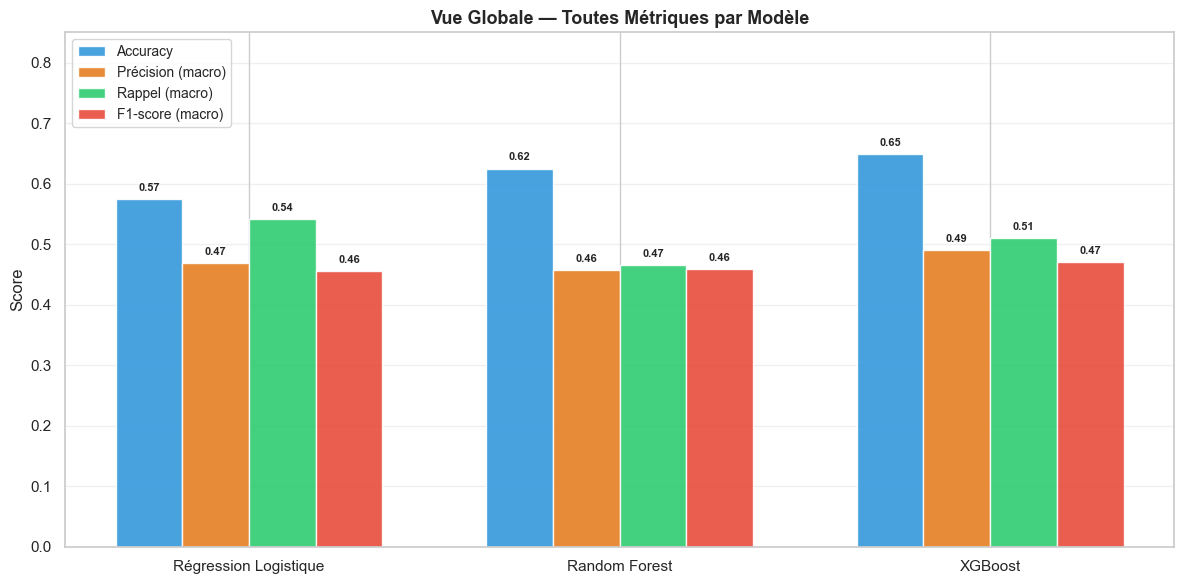

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

# Positions des groupes de barres sur l'axe x
x    = np.arange(len(modeles))
larg = 0.18  # largeur de chaque barre

# Une barre par métrique, groupées par modèle
b1 = ax.bar(x - 1.5*larg, df['Accuracy'],          larg, label='Accuracy',          color='#3498db', alpha=0.9)
b2 = ax.bar(x - 0.5*larg, df['Précision (macro)'], larg, label='Précision (macro)', color='#e67e22', alpha=0.9)
b3 = ax.bar(x + 0.5*larg, df['Rappel (macro)'],    larg, label='Rappel (macro)',    color='#2ecc71', alpha=0.9)
b4 = ax.bar(x + 1.5*larg, df['F1-score (macro)'],  larg, label='F1-score (macro)',  color='#e74c3c', alpha=0.9)

# Valeurs affichées sur chaque barre
for groupe in [b1, b2, b3, b4]:
    for barre in groupe:
        val = barre.get_height()
        ax.text(
            barre.get_x() + barre.get_width() / 2,
            val + 0.01,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold'
        )

ax.set_title('Vue Globale — Toutes Métriques par Modèle', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modeles, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 0.85)
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Analyse par Classe — F1-score

Le F1-score par classe révèle les forces et faiblesses de chaque modèle sur chaque niveau de gravité.

La classe **Tué** est la plus critique : dans un contexte de sécurité routière,
**manquer un accident mortel (faux négatif) est bien plus grave** que le prédire à tort (faux positif).

C:\Users\user\AppData\Local\Temp\ipykernel_10828\1531027312.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(modeles, rotation=20, ha='right', fontsize=9)
C:\Users\user\AppData\Local\Temp\ipykernel_10828\1531027312.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(modeles, rotation=20, ha='right', fontsize=9)
C:\Users\user\AppData\Local\Temp\ipykernel_10828\1531027312.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(modeles, rotation=20, ha='right', fontsize=9)


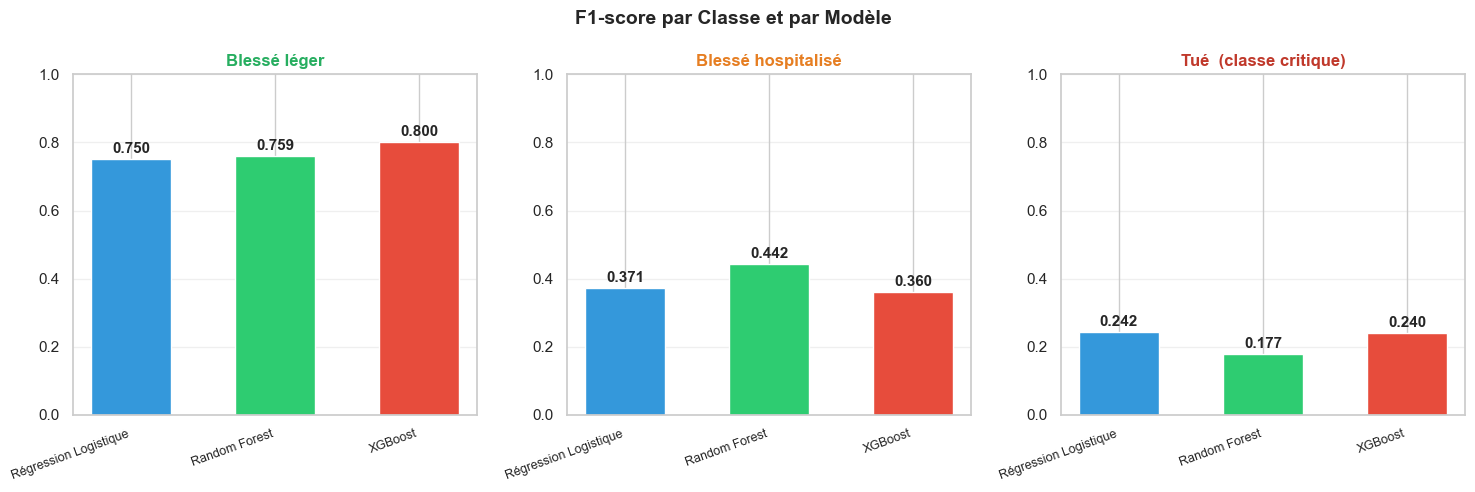


F1-score par classe :
                       F1 — Blessé léger  F1 — Blessé hospitalisé  F1 — Tué
Modèle                                                                     
Régression Logistique              0.750                    0.371     0.242
Random Forest                      0.759                    0.442     0.177
XGBoost                            0.800                    0.360     0.240


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('F1-score par Classe et par Modèle', fontsize=14, fontweight='bold')

couleurs_modeles = ['#3498db', '#2ecc71', '#e74c3c']

# Informations pour chaque sous-graphique : (colonne du df, titre, couleur du titre)
infos_classes = [
    ('F1 — Blessé léger',       'Blessé léger',         '#27ae60'),
    ('F1 — Blessé hospitalisé', 'Blessé hospitalisé',   '#e67e22'),
    ('F1 — Tué',                'Tué  (classe critique)', '#c0392b'),
]

for ax, (colonne, titre, couleur_titre) in zip(axes, infos_classes):
    valeurs = df_classes[colonne].values
    barres  = ax.bar(modeles, valeurs, color=couleurs_modeles, edgecolor='white', width=0.55)

    for barre, val in zip(barres, valeurs):
        ax.text(
            barre.get_x() + barre.get_width() / 2,
            barre.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11
        )

    ax.set_title(titre, fontweight='bold', fontsize=12, color=couleur_titre)
    ax.set_ylim(0, 1.0)
    ax.set_xticklabels(modeles, rotation=20, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Tableau récapitulatif par classe
print()
print('F1-score par classe :')
print(df_classes.round(3).to_string())

## 7. Analyse et Interprétation des Résultats

### 7.1 Performances Globales

D'après les graphiques :

- **XGBoost** obtient les **meilleures performances globales** :
  - Accuracy la plus élevée : **0.649** → le plus de prédictions correctes
  - F1-score macro le plus élevé : **0.470** → le plus équilibré sur les 3 classes
  - Meilleur rappel macro : **0.510**

- **Régression Logistique** et **Random Forest** ont des F1 macro proches (0.455 vs 0.459),
  mais le Random Forest a une meilleure accuracy (0.625 vs 0.574).

---

### 7.2 Analyse par Classe

| Classe | Meilleur F1 | Modèle gagnant |
|--------|------------|----------------|
| Blessé léger | 0.800 | XGBoost |
| Blessé hospitalisé | 0.442 | **Random Forest** |
| **Tué** (critique) | **0.242** | **Régression Logistique** |

> Tous les modèles peinent sur la classe Tué (F1 ≤ 0.25) en raison du fort déséquilibre (5.9%).

---

### 7.3 Pourquoi le Rappel est Particulièrement Important ?

Dans un problème de **sécurité routière**, les erreurs ne se valent pas :

- **Faux Négatif** = prédire "Blessé léger" alors que l'accident est mortel → **très grave**
  - Les autorités sous-estiment le danger et n'allouent pas les ressources nécessaires

- **Faux Positif** = prédire "Tué" alors que c'est un blessé léger → **moins grave**
  - Gaspillage de ressources, mais pas de mise en danger directe

**Conclusion :** Dans ce contexte, il vaut mieux **maximiser le rappel** sur la classe Tué.
La Régression Logistique obtient le meilleur rappel sur cette classe (**0.609**),
ce qui peut la rendre préférable si c'est la priorité métier.

---

### 7.4 Comprendre les Métriques : Accuracy, Précision, Rappel, F1

| Métrique | Ce qu'elle mesure | Limite dans notre cas |
|----------|------------------|-----------------------|
| **Accuracy** | % de prédictions correctes globalement | Trompeuse avec des classes déséquilibrées |
| **Précision** | Parmi les cas prédits positifs, combien sont vrais | Faible si beaucoup de faux positifs |
| **Rappel** | Parmi les vrais cas, combien sont détectés | Crucial pour ne pas rater les accidents mortels |
| **F1-score** | Moyenne harmonique précision / rappel | Meilleur compromis — à privilégier ici |

> **Exemple concret :** Un modèle qui prédirait toujours "Blessé léger" obtiendrait
> 64 % d'accuracy **sans rien apprendre**. C'est pourquoi le **F1-score macro**
> est la métrique principale de ce projet.

## 8. Conclusion Finale

### Récapitulatif des Performances

| Modèle | Accuracy | F1 Macro | F1 Tué | Points forts |
|--------|----------|----------|--------|--------------|
| Régression Logistique | 0.574 | 0.455 | 0.242 | Meilleur rappel sur Tué, interprétable via les coefficients |
| Random Forest | 0.625 | 0.459 | 0.177 | Bon sur Blessé hospitalisé, robuste et stable |
| **XGBoost** | **0.649** | **0.470** | **0.240** | **Meilleur globalement** |

---

### Modèle Recommandé : XGBoost

**XGBoost est le modèle recommandé** pour prédire la gravité des accidents routiers :

- Meilleure accuracy globale (0.649)
- Meilleur F1-score macro (0.470) — performances équilibrées sur les 3 classes
- Meilleur F1 sur Blessé léger (0.800)
- Meilleur rappel global (0.510)

---

### Nuances selon le Cas d'Usage

Le meilleur modèle **dépend de l'objectif prioritaire** :

- **Ne pas manquer d'accidents mortels** → Régression Logistique (rappel Tué = 0.609)
- **Performance globale équilibrée** → XGBoost
- **Interprétabilité et simplicité** → Régression Logistique (coefficients lisibles)

---

### Limites Communes à Tous les Modèles

- La classe **Tué** reste difficile à prédire pour tous les modèles (F1 ≤ 0.25)
- Le fort déséquilibre des classes (ratio 11×) est un frein structurel
- Les 12 variables disponibles ne capturent pas tous les facteurs de gravité
  (vitesse réelle au moment du choc, port de ceinture, état physique des conducteurs…)